# Practice 3: Exercise 2 — Finetuned DistilBERT Sentiment Analysis on IMDB

## Overview & Purpose
This notebook demonstrates and analyzes Exercise 2 of Practice 3:
1. **Finetuning Recap:** DistilBERT (`distilbert-base-uncased`) finetuned on the IMDB binary sentiment dataset with the HF `Trainer` — run via [`src/training/imdb_sentiment_train.py`](../src/training/imdb_sentiment_train.py) (script-only, rules [`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md)).
2. **Run Artifacts:** Training history (JSONL), config, checkpoints (`<run>_best.pt`, `<run>_last.pt`), TensorBoard logs under `experiments/runs/`.
3. **Test-Set Evaluation:** Loading [`experiments/results/imdb_sentiment_eval.json`](../experiments/results/imdb_sentiment_eval.json) produced by [`src/eval/evaluate_model.py`](../src/eval/evaluate_model.py) — accuracy, confusion matrix, per-class precision/recall/F1 (5W1H).
4. **Baseline Comparison:** Finetuned model vs the Ex 1 zero-shot floor (89.07%).

> **Note:** Per project rules, notebooks **never contain a training loop** — they load persisted artifacts produced by scripts.

## Roadmap Table
| Step | Description | What it does | Import path |
|:---:|:---|:---|:---|
| 1 | Run config & latest run | Locate `experiments/runs/<ts>_<run>/` and read logged config | [`src/training/imdb_sentiment_train.py`](../src/training/imdb_sentiment_train.py) |
| 2 | Training history | Load JSONL history, plot eval_loss/accuracy/f1 vs epoch | [`experiments/runs/`](../experiments/runs/) |
| 3 | Test-set evaluation | Load eval JSON: accuracy, confusion matrix, per-class P/R/F1 | [`src/eval/evaluate_model.py`](../src/eval/evaluate_model.py) |
| 4 | Sample predictions | Load `<run>_best.pt`, predict on sample reviews | [`experiments/runs/`](../experiments/runs/) |
| 5 | Baseline comparison | Ex 1 zero-shot vs Ex 2 finetuned head-to-head | [`experiments/results/`](../experiments/results/) |

---

## References
- **Rulebase:** [`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md), [`RESULTS_REPORTING.md`](../agents/rules/RESULTS_REPORTING.md), [`NOTEBOOK_HEADER_CONVENTION.md`](../agents/rules/NOTEBOOK_HEADER_CONVENTION.md)
- **Training Script Entry Point:** [`src/training/imdb_sentiment_train.py`](../src/training/imdb_sentiment_train.py)
- **Eval Script Entry Point:** [`src/eval/evaluate_model.py`](../src/eval/evaluate_model.py)
- **Data Prep Script:** [`src/data/prepare_imdb.py`](../src/data/prepare_imdb.py)
- **Persisted Artifacts:** [`experiments/results/imdb_sentiment_eval.json`](../experiments/results/imdb_sentiment_eval.json), [`experiments/results/baseline_imdb_sentiment.json`](../experiments/results/baseline_imdb_sentiment.json), [`experiments/runs/registry.json`](../experiments/runs/registry.json)
- **Hugging Face Model:** [`distilbert-base-uncased`](https://huggingface.co/distilbert-base-uncased)
- **Hugging Face Dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb)


In [1]:
import sys
import json
from pathlib import Path

import torch
from IPython.display import Image, display
from transformers import AutoModelForSequenceClassification, AutoTokenizer

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Device:       {device_name} ({device})")


Project Root: /home/bush/Desktop/Deeplearning_Course_UTH
Device:       NVIDIA GeForce RTX 3050 Laptop GPU (cuda)


In [2]:
# Step 1: Locate the latest distilbert-finetune run and show its config
from src.utils.checkpoint_utils import latest_run_dir

run_dir = latest_run_dir(PROJECT_ROOT / "experiments/runs", "distilbert-finetune")
print("Latest run dir:", run_dir)

if run_dir is None:
    print("\nNo run found. Produce it with:")
    print("  python -m src.training.imdb_sentiment_train --epochs 3 --seed 42 --tb")
else:
    config_path = run_dir / "metrics" / "distilbert-finetune_config.json"
    if config_path.exists():
        with open(config_path, encoding="utf-8") as f:
            cfg_data = json.load(f)
        config = cfg_data["config"]
        print("=" * 65)
        print(" RUN CONFIG (distilbert-base-uncased on IMDB)")
        print("=" * 65)
        t = config["training"]
        print(f"Model:            {config['model']['name']}")
        print(f"Num labels:       {config['model']['num_labels']}  id2label={config['model']['id2label']}")
        print(f"Epochs:           {t['epochs']}")
        print(f"Learning rate:    {t['lr']}")
        print(f"Batch size:       {t['batch_size']}  (grad accum {t['gradient_accumulation_steps']})")
        print(f"Weight decay:     {t['weight_decay']}")
        print(f"FP16:             {t['fp16']}")
        print(f"Max length:       {config['data'].get('max_length')}")
        print(f"VRAM budget:      {t.get('vram_budget_gb')} GB")
        print(f"Splits:           {config.get('data', {}).get('tokenized_splits')}")
        print("=" * 65)
    else:
        print("config.json not found yet — run the training script first.")


Latest run dir: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/runs/20260812_175932_distilbert-finetune
 RUN CONFIG (distilbert-base-uncased on IMDB)
Model:            distilbert-base-uncased
Num labels:       2  id2label={'0': 'neg', '1': 'pos'}
Epochs:           4
Learning rate:    1.5e-05
Batch size:       8  (grad accum 2)
Weight decay:     0.05
FP16:             True
Max length:       256
VRAM budget:      3.5 GB
Splits:           {'test': 25000, 'train': 22500, 'val': 2500}


Loaded 19 history entries from /home/bush/Desktop/Deeplearning_Course_UTH/experiments/runs/20260812_175932_distilbert-finetune/metrics/distilbert-finetune_history.jsonl
--- Per-epoch eval metrics ---
Epoch 0.21329541414859582: eval_loss=0.3290 eval_acc=0.8636 eval_f1=0.8683
Epoch 0.42659082829719164: eval_loss=0.2753 eval_acc=0.8832 eval_f1=0.8817
Epoch 0.6398862424457874: eval_loss=0.2910 eval_acc=0.8864 eval_f1=0.8898
Epoch 0.8531816565943833: eval_loss=0.2671 eval_acc=0.8840 eval_f1=0.8809
Epoch 1.0661215783860647: eval_loss=0.3583 eval_acc=0.8828 eval_f1=0.8910
Epoch 1.2794169925346606: eval_loss=0.3040 eval_acc=0.8976 eval_f1=0.8940
Epoch 1.4927124066832564: eval_loss=0.2957 eval_acc=0.8976 eval_f1=0.8935
Epoch 1.706007820831852: eval_loss=0.3929 eval_acc=0.8716 eval_f1=0.8594
Epoch 1.919303234980448: eval_loss=0.2925 eval_acc=0.9052 eval_f1=0.9042
Epoch 2.1322431567721294: eval_loss=0.3822 eval_acc=0.9044 eval_f1=0.9022
Epoch 2.3455385709207253: eval_loss=0.3995 eval_acc=0.9056 e

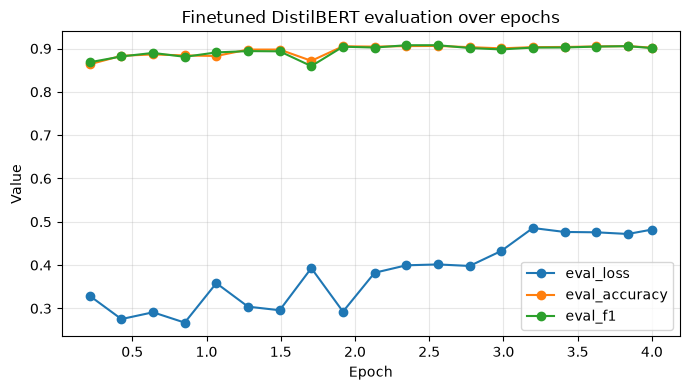

(analysis plot saved to /home/bush/Desktop/Deeplearning_Course_UTH/experiments/plots/imdb_finetune_history.png)


In [3]:
# Step 2: Load and display the persisted per-epoch training history (JSONL)
import matplotlib.pyplot as plt

history_jsonl = run_dir / "metrics" / "distilbert-finetune_history.jsonl"
history = []
if history_jsonl.exists():
    with open(history_jsonl, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                history.append(json.loads(line))
    print(f"Loaded {len(history)} history entries from {history_jsonl}")
else:
    print("history.jsonl not found yet — run the training script first.")

if history:
    keys = ["eval_loss", "eval_accuracy", "eval_f1"]
    print("--- Per-epoch eval metrics ---")
    for row in history:
        if "eval_loss" in row:
            print(f"Epoch {row['epoch']}: eval_loss={row.get('eval_loss'):.4f} "
                  f"eval_acc={row.get('eval_accuracy'):.4f} eval_f1={row.get('eval_f1'):.4f}")

    arrivals = [k for k in keys if history[-1].get(k) is not None]
    if len(arrivals) >= 2:
        fig, ax = plt.subplots(figsize=(7, 4))
        xs = [r["epoch"] for r in history if "eval_loss" in r]
        for key in arrivals:
            ax.plot(xs, [r[key] for r in history if "eval_loss" in r], marker="o", label=key)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")
        ax.set_title("Finetuned DistilBERT evaluation over epochs")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plot_out = PROJECT_ROOT / "experiments" / "plots" / "imdb_finetune_history.png"
        plt.savefig(plot_out, dpi=150)
        plt.show()
        print(f"(analysis plot saved to {plot_out})")


 PERSISTED 5W1H METADATA & FINETUNED MODEL EVALUATION (TEST SPLIT)
Who:   bush-le + AI agent — coursework submission
What:  Finetuned DistilBERT test-set evaluation (accuracy, ROC-AUC, confusion matrix, per-class P/R/F1)
When:  2026-08-12T18:23:28.181868
Where: experiments/results/imdb_sentiment_eval.json | executed on cuda
Why:   Generalization benchmark on sealed IMDB test split vs Exercise 1 zero-shot floor
How:   single held-out evaluation pass, softmax probability output, no TTA

--- Metric Summary ---
Checkpoint:            experiments/runs/20260812_175932_distilbert-finetune/checkpoints/distilbert-finetune_best.pt
Evaluated Test Samples: 25,000
Test Accuracy:          91.19%
F1 (macro):             0.9119
Per-class (neg / pos):
  neg: precision=0.9107 recall=0.9134 f1=0.9120 support=12500
  pos: precision=0.9131 recall=0.9104 f1=0.9117 support=12500
Confusion matrix [[TN, FP], [FN, TP]]:
  11,417  1,083
  1,120  11,380

--- Confusion Matrix Plot ---


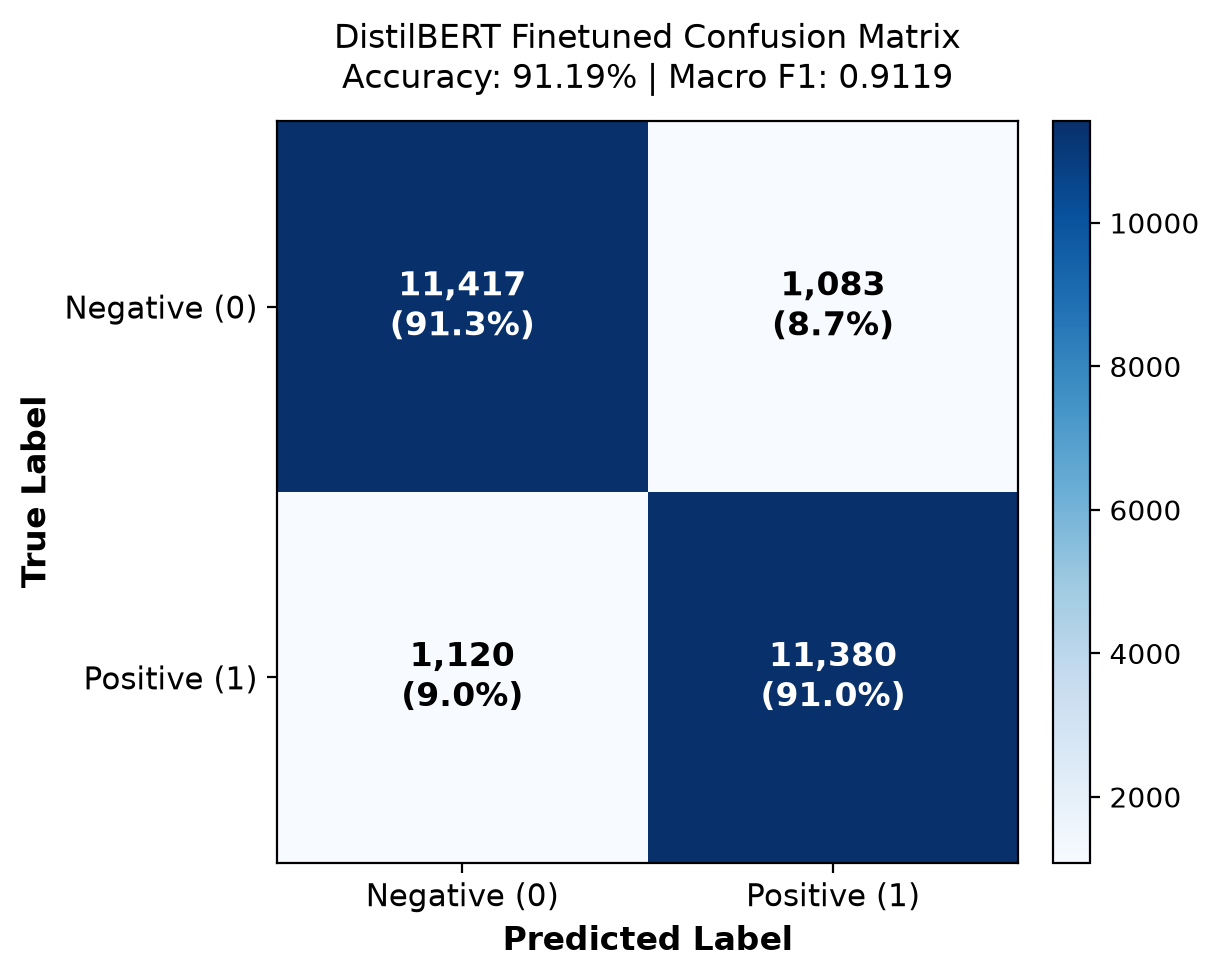


--- Test Set ROC Curve Plot ---


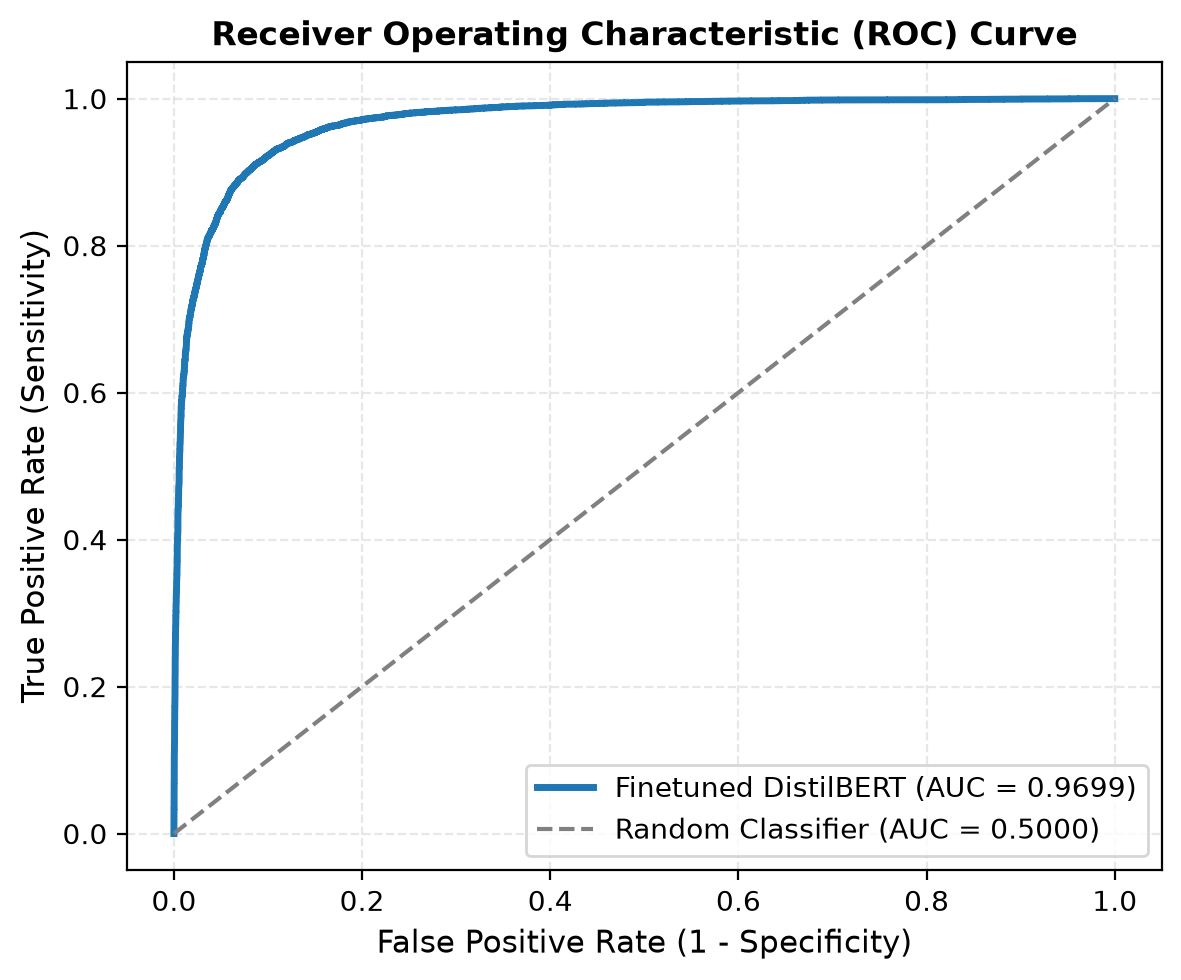

In [4]:
# Step 3: Load persisted test-set evaluation (accuracy, confusion matrix, per-class P/R/F1)
eval_path = PROJECT_ROOT / "experiments" / "results" / "imdb_sentiment_eval.json"

if not eval_path.exists():
    print(f"Artifact not found at {eval_path}. Please run:")
    print("  python -m src.eval.evaluate_model --best")
else:
    with open(eval_path, encoding="utf-8") as f:
        payload = json.load(f)
    meta = payload["metadata_5w1h"]
    r = payload["result"]

    print("=" * 65)
    print(" PERSISTED 5W1H METADATA & FINETUNED MODEL EVALUATION (TEST SPLIT)")
    print("=" * 65)
    print(f"Who:   {meta['who']}")
    print(f"What:  {meta['what']}")
    print(f"When:  {meta['when']}")
    print(f"Where: {meta['where']}")
    print(f"Why:   {meta['why']}")
    print(f"How:   {meta['how']}")

    print("\n--- Metric Summary ---")
    print(f"Checkpoint:            {r['checkpoint']}")
    print(f"Evaluated Test Samples: {r['num_test_samples']:,}")
    print(f"Test Accuracy:          {r['accuracy'] * 100.0:.2f}%")
    print(f"F1 (macro):             {r['f1_macro']:.4f}")
    print("Per-class (neg / pos):")
    for cls in ("neg", "pos"):
        pc = r["per_class"][cls]
        print(f"  {cls}: precision={pc['precision']:.4f} recall={pc['recall']:.4f} f1={pc['f1']:.4f} support={pc['support']}")
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    cm = r["confusion_matrix"]
    print(f"  {cm['neg_neg']:,}  {cm['neg_pos']:,}")
    print(f"  {cm['pos_neg']:,}  {cm['pos_pos']:,}")
    print("=" * 65)

    cm_plot = PROJECT_ROOT / "experiments" / "plots" / "imdb_finetuned_confusion_matrix.png"
    if cm_plot.exists():
        print("\n--- Confusion Matrix Plot ---")
        display(Image(filename=str(cm_plot)))

    roc_plot = PROJECT_ROOT / "experiments" / "plots" / "imdb_finetuned_roc_curve.png"
    if roc_plot.exists():
        print("\n--- Test Set ROC Curve Plot ---")
        display(Image(filename=str(roc_plot)))


In [5]:
# Step 4: Local interpretability — sample predictions from the finetuned checkpoint
best_pt = run_dir / "checkpoints" / "distilbert-finetune_best.pt"
if best_pt.exists():
    ckpt = torch.load(best_pt, map_location="cpu", weights_only=True)
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    samples = [
        "This movie was absolutely fantastic! The acting was superb.",
        "Terrible pacing, boring dialogue, and a nonsensical ending.",
        "It has great visuals but the story is completely forgettable.",
    ]
    print("--- Finetuned model predictions ---")
    with torch.no_grad():
        for text in samples:
            enc = tokenizer(text, truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)[0]
            pred = int(logits.argmax(-1))
            label = "pos (1)" if pred == 1 else "neg (0)"
            print(f'Input:  "{text}"')
            print(f"Predict: {label}  confidence pos={probs[1]:.4f} neg={probs[0]:.4f}\n")
else:
    print("Best checkpoint not found — run the training script first.")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- Finetuned model predictions ---
Input:  "This movie was absolutely fantastic! The acting was superb."
Predict: pos (1)  confidence pos=0.9988 neg=0.0012

Input:  "Terrible pacing, boring dialogue, and a nonsensical ending."
Predict: neg (0)  confidence pos=0.0012 neg=0.9988

Input:  "It has great visuals but the story is completely forgettable."
Predict: neg (0)  confidence pos=0.0014 neg=0.9986



In [6]:
# Step 5: Compare finetuned model vs the Ex 1 zero-shot baseline
import IPython.display as disp

baseline_path = PROJECT_ROOT / "experiments" / "results" / "baseline_imdb_sentiment.json"
finetuned_path = PROJECT_ROOT / "experiments" / "results" / "imdb_sentiment_eval.json"

rows = []
if baseline_path.exists():
    with open(baseline_path, encoding="utf-8") as f:
        b = json.load(f)["evaluation"]
    rows.append(("Ex 1 zero-shot (baseline)", f"{b['zero_shot_accuracy'] * 100:.2f}%",
                 "N/A", f"{b.get('zero_shot_roc_auc', float('nan')):.4f}"))
if finetuned_path.exists():
    with open(finetuned_path, encoding="utf-8") as f:
        f_acc = json.load(f)["result"]
    rows.append(("Ex 2 finetuned DistilBERT", f"{f_acc['accuracy'] * 100:.2f}%",
                 f"{f_acc['f1_macro']:.4f}", "computed on test set once"))

if rows:
    table = disp.HTML(
        "<table><tr><th>Model</th><th>Test Accuracy</th><th>F1 (macro)</th><th>ROC-AUC</th></tr>"
        + "".join(f"<tr><td>{a}</td><td>{c}</td><td>{d}</td><td>{e}</td></tr>" for a, c, d, e in rows)
        + "</table>"
    )
    disp.display(table)
    print("5W1H: what=test accuracy head-to-head; when=2026-08-12; where=experiments/results/; "
          "who=bush-le + AI agent -> coursework; how=single held-out evaluation, no TTA.")
else:
    print("Run both evaluation steps first (Ex 1 baseline + Ex 2 eval).")


Model,Test Accuracy,F1 (macro),ROC-AUC
Ex 1 zero-shot (baseline),89.07%,N/A,0.9587
Ex 2 finetuned DistilBERT,91.19%,0.9119,computed on test set once


5W1H: what=test accuracy head-to-head; when=2026-08-12; where=experiments/results/; who=bush-le + AI agent -> coursework; how=single held-out evaluation, no TTA.


In [ ]:
# Step 6: Root Cause Error Analysis & Misclassifications Breakdown
import importlib
import scratch.analyze_misclassifications

importlib.reload(scratch.analyze_misclassifications)
scratch.analyze_misclassifications.analyze_errors()


Loading checkpoint for error analysis: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/runs/20260812_175932_distilbert-finetune/checkpoints/distilbert-finetune_best.pt


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized
Running inference on 25,000 test samples...
